In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [8]:
numeric_features = df.select_dtypes(include=[np.number])
numeric_features

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


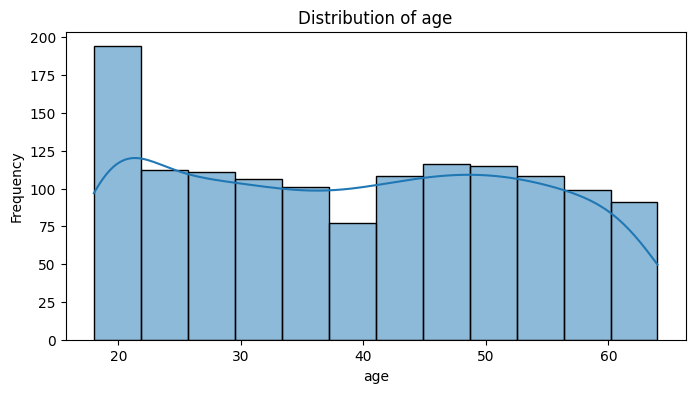

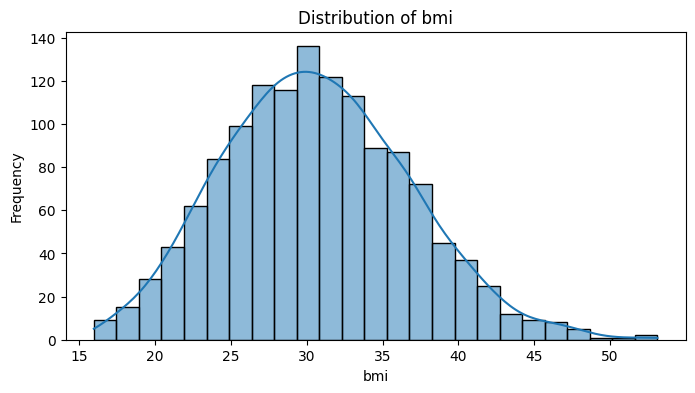

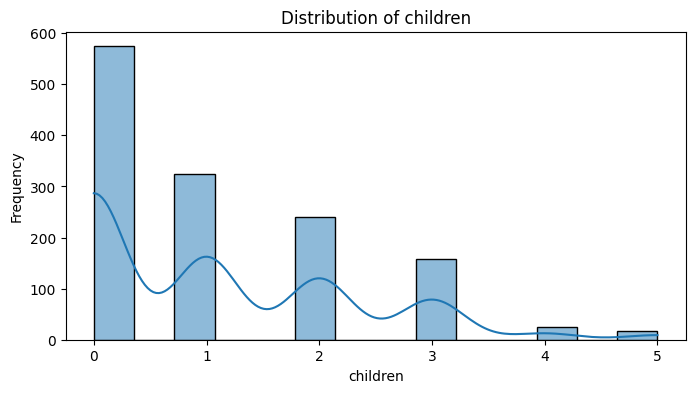

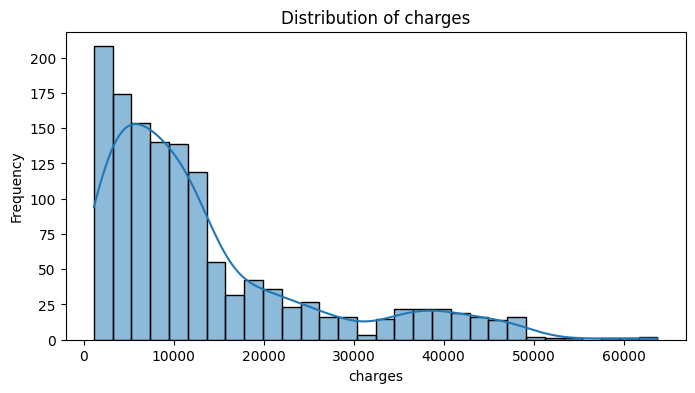

In [9]:
#plot numeric features
for col in numeric_features.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(numeric_features[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

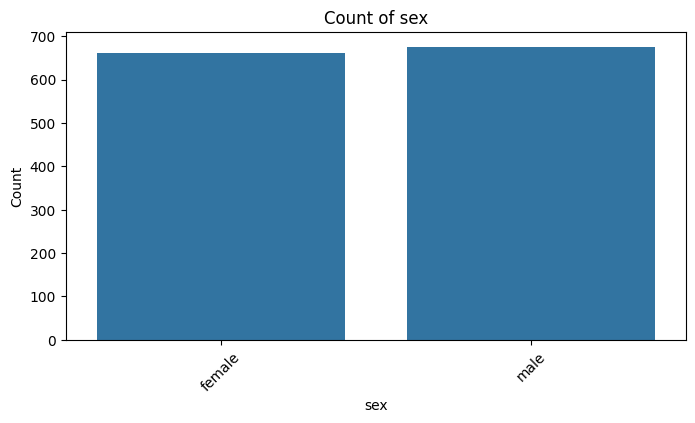

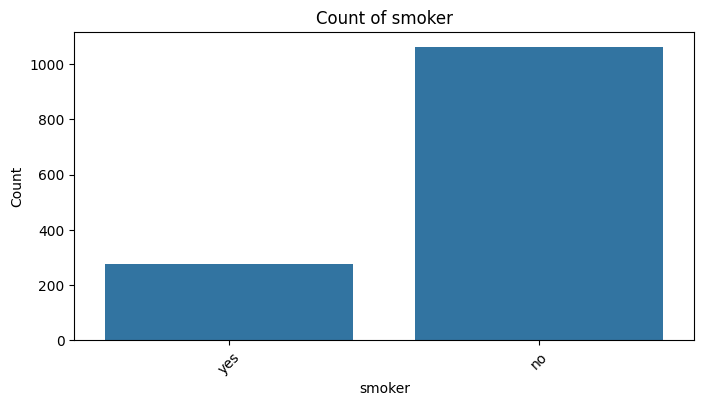

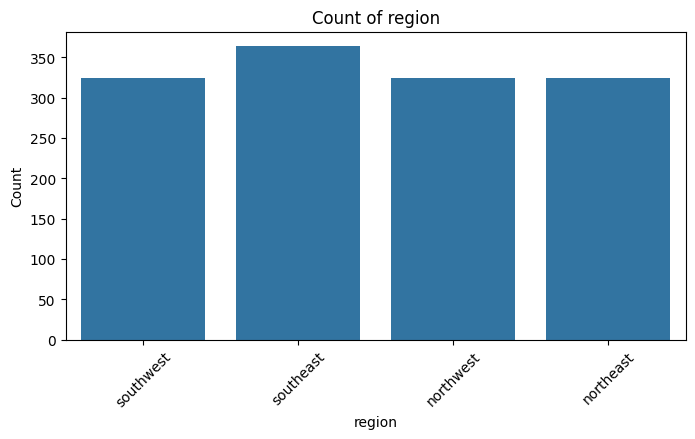

In [10]:
#countplot for categorical features to see the distribution of categories
categorical_features = df.select_dtypes(include=[object])
for col in categorical_features.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x=categorical_features[col])
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

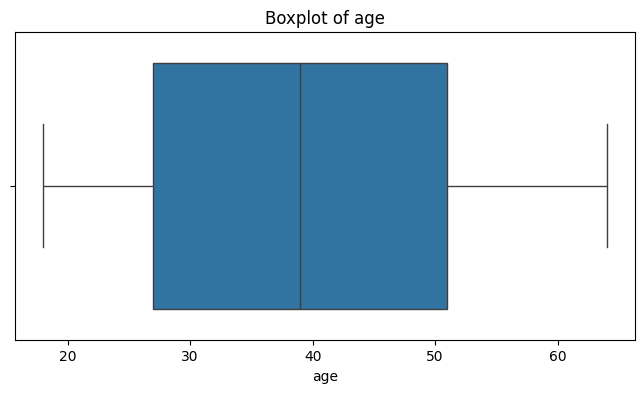

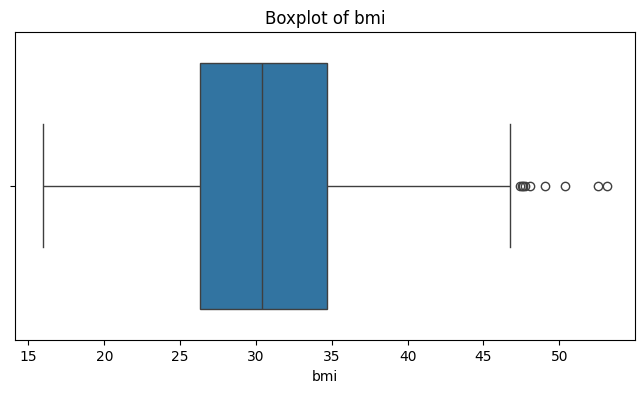

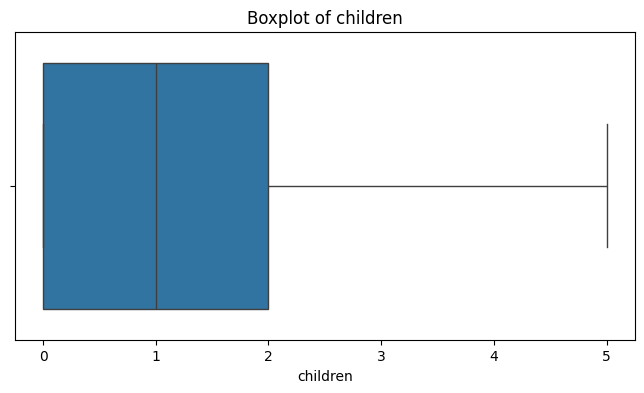

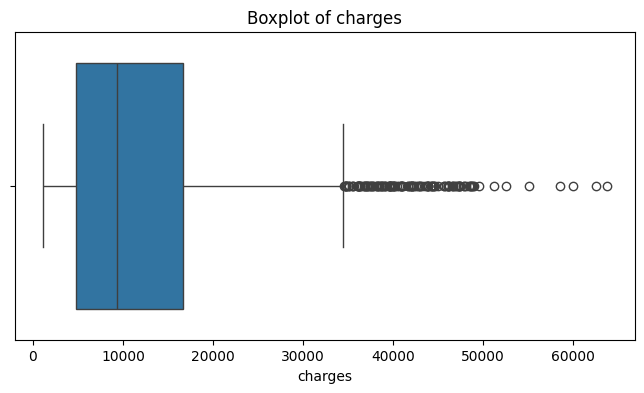

In [11]:
#boxplot
for col in numeric_features.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

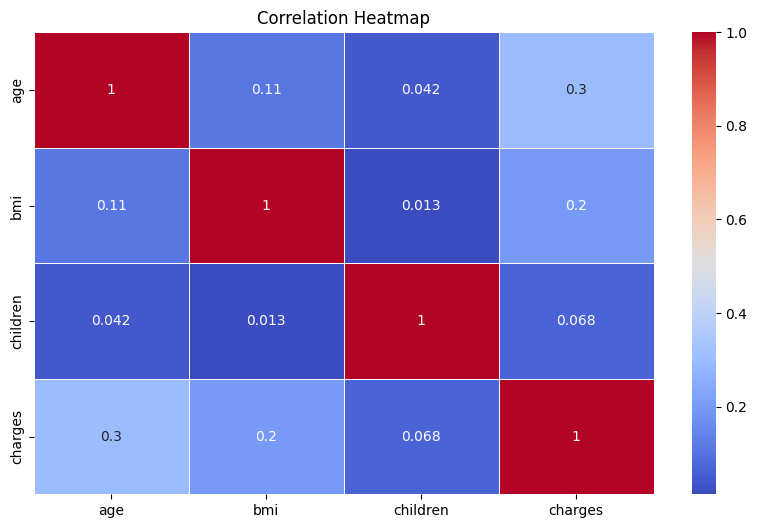

In [12]:
#correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(numeric_features.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [13]:
# data cleaning
df_cleaned = df.copy()
print(df_cleaned.shape)
df_cleaned.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [14]:
#drop duplicates
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.shape

(1337, 7)

In [15]:
#value counts for categorical features to check for inconsistencies
for col in categorical_features.columns:
    print(f"Value counts for {col}:")
    print(df_cleaned[col].value_counts())
    print("\n")

Value counts for sex:
sex
male      675
female    662
Name: count, dtype: int64


Value counts for smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64


Value counts for region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64




In [16]:
#label encoding for categorical features sex,smoker
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_cleaned["sex"] = le.fit_transform(df_cleaned["sex"])
df_cleaned["smoker"] = le.fit_transform(df_cleaned["smoker"])   
df_cleaned.head()



,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [17]:
#cont of categorical features after encoding
for col in categorical_features.columns: 
    print(f"Value counts for {col}:")
    print(df_cleaned[col].value_counts())
    print("\n")


Value counts for sex:
sex
1    675
0    662
Name: count, dtype: int64


Value counts for smoker:
smoker
0    1063
1     274
Name: count, dtype: int64


Value counts for region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64




In [18]:
#one-hot encoding for region
df_cleaned = pd.get_dummies(df_cleaned, columns=["region"], drop_first=True)
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [19]:
#lebel encoding for region_northwest, region_southwest, region_southeast using loop
df_cleaned=df_cleaned.astype(int)
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27,0,1,16884,0,0,1
1,18,1,33,1,0,1725,0,1,0
2,28,1,33,3,0,4449,0,1,0
3,33,1,22,0,0,21984,1,0,0
4,32,1,28,0,0,3866,1,0,0


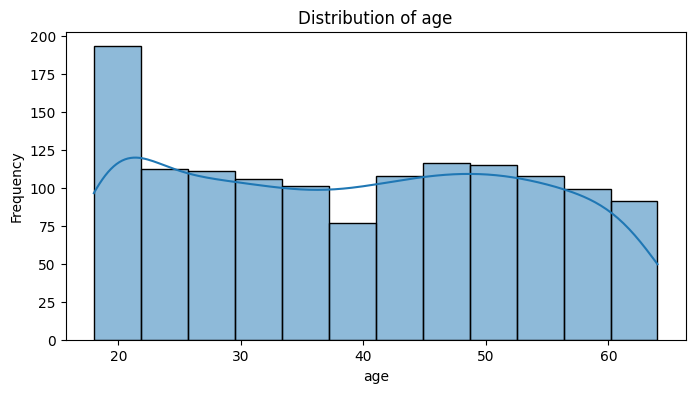

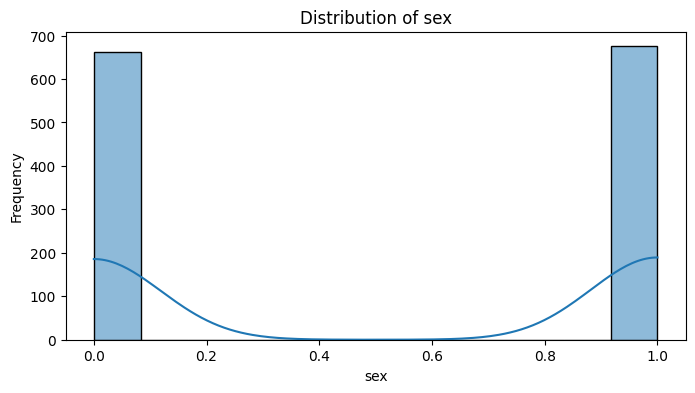

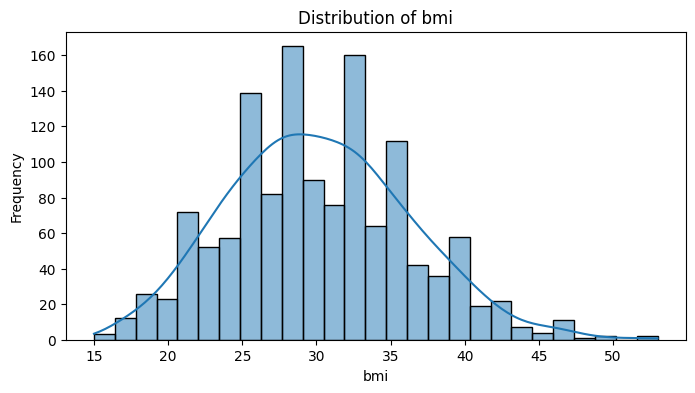

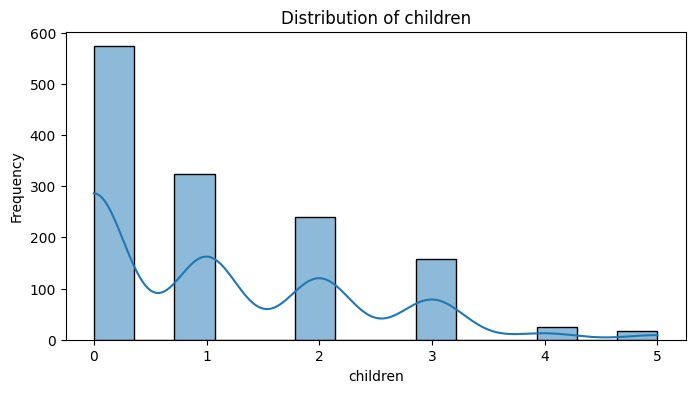

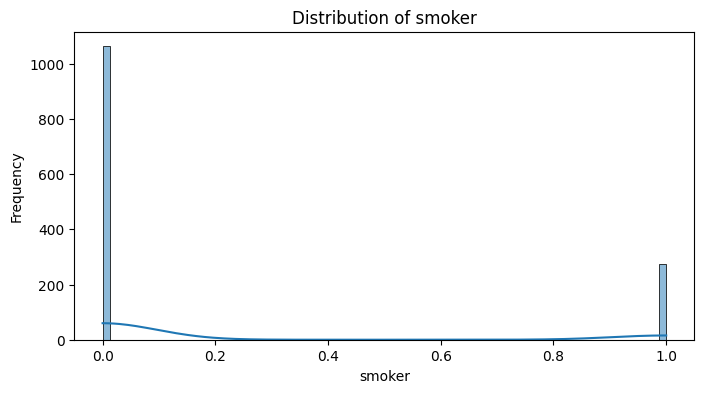

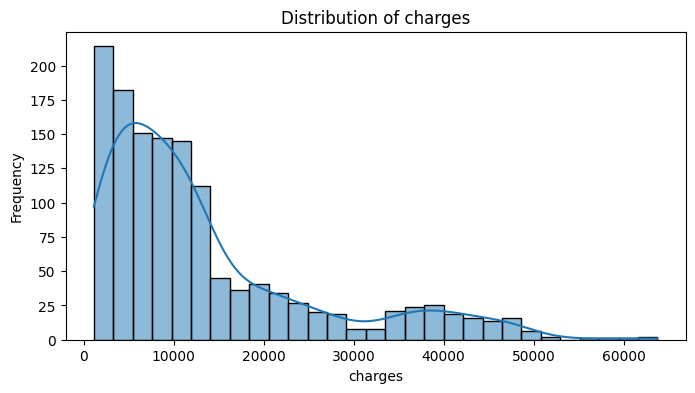

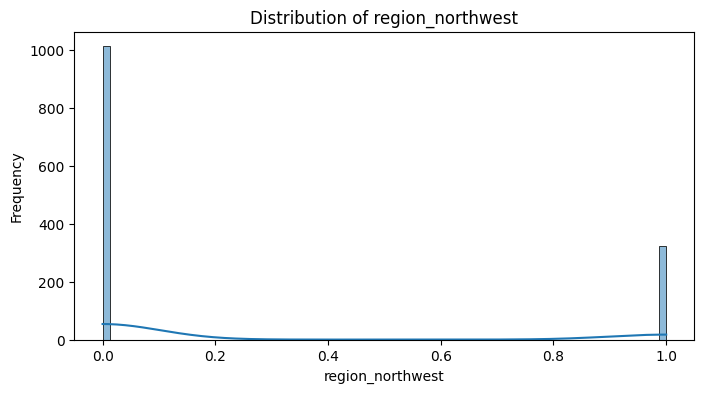

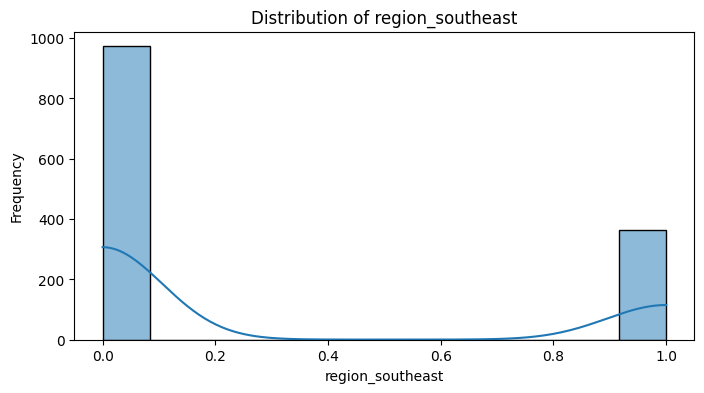

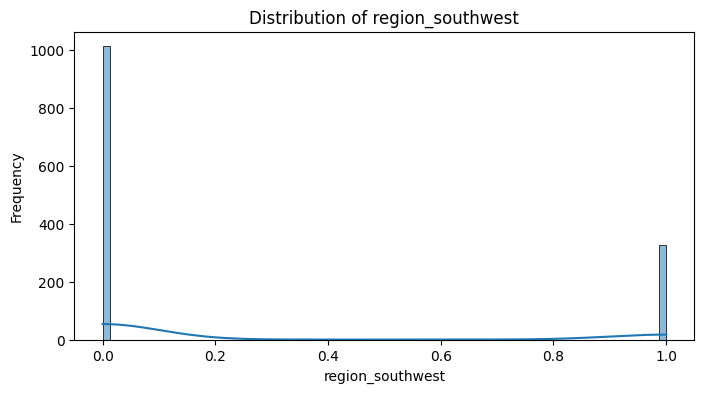

In [20]:
# Feature engineering and extraction
#create histogram to see the distribution of all features
for col in df_cleaned.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df_cleaned[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()







In [21]:
#made bmi categories
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif 18.5 <= bmi < 25:
        return "Normal weight"
    elif 25 <= bmi < 30:
        return "Overweight"
    else:
        return "Obese"
    
df_cleaned["bmi_category"] = df_cleaned["bmi"].apply(bmi_category)
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,0,27,0,1,16884,0,0,1,Overweight
1,18,1,33,1,0,1725,0,1,0,Obese
2,28,1,33,3,0,4449,0,1,0,Obese
3,33,1,22,0,0,21984,1,0,0,Normal weight
4,32,1,28,0,0,3866,1,0,0,Overweight


bmi_category
Obese            706
Overweight       386
Normal weight    221
Underweight       24
Name: count, dtype: int64


Text(0.5, 1.0, 'Count of BMI Categories')

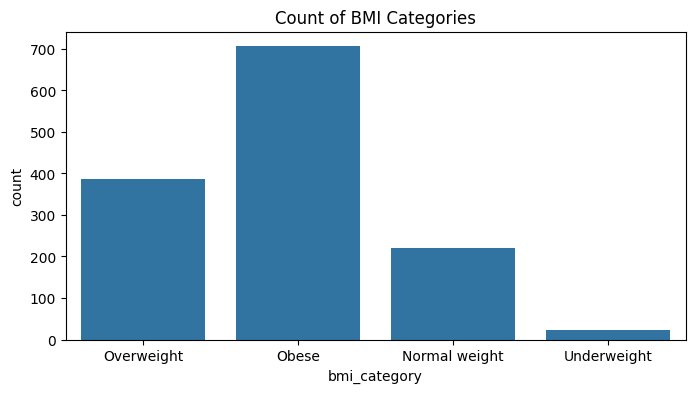

In [22]:
#count of bmi categories
print(df_cleaned["bmi_category"].value_counts())
#histogram of bmi categories
plt.figure(figsize=(8,4))
sns.countplot(x=df_cleaned["bmi_category"])
plt.title("Count of BMI Categories")


In [23]:
#onehot encoding for bmi_category to bmi_normal_weight, bmi_overweight, bmi_obese,bmi_underweight
df_cleaned = pd.get_dummies(df_cleaned, columns=["bmi_category"])
df_cleaned.head()



,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight
0,19,0,27,0,1,16884,0,0,1,False,False,True,False
1,18,1,33,1,0,1725,0,1,0,False,True,False,False
2,28,1,33,3,0,4449,0,1,0,False,True,False,False
3,33,1,22,0,0,21984,1,0,0,True,False,False,False
4,32,1,28,0,0,3866,1,0,0,False,False,True,False


In [24]:
df_cleaned=df_cleaned.astype(int)
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight
0,19,0,27,0,1,16884,0,0,1,0,0,1,0
1,18,1,33,1,0,1725,0,1,0,0,1,0,0
2,28,1,33,3,0,4449,0,1,0,0,1,0,0
3,33,1,22,0,0,21984,1,0,0,1,0,0,0
4,32,1,28,0,0,3866,1,0,0,0,0,1,0


In [25]:
#Scaling the age,bmi,children features using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
columns_to_scale = ["age", "bmi", "children"]
df_cleaned[columns_to_scale] = scaler.fit_transform(df_cleaned[columns_to_scale])
df_cleaned.head()


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight
0,-1.440418,0,-0.517949,-0.909234,1,16884,0,0,1,0,0,1,0
1,-1.511647,1,0.462463,-0.079442,0,1725,0,1,0,0,1,0,0
2,-0.799350,1,0.462463,1.580143,0,4449,0,1,0,0,1,0,0
3,-0.443201,1,-1.334960,-0.909234,0,21984,1,0,0,1,0,0,0
4,-0.514431,1,-0.354547,-0.909234,0,3866,1,0,0,0,0,1,0


In [26]:
#Feature extraction using pearson correlation using scipy
from scipy.stats import pearsonr

selected_features = df_cleaned.columns[df_cleaned.columns != "charges"]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned["charges"])[0]
    for feature in selected_features

}
correlations_df = pd.DataFrame.from_dict(correlations, orient="index", columns=["Pearson Correlation"])
correlations_df.sort_values(by="Pearson Correlation", ascending=False, inplace=True)
correlations_df

,Pearson Correlation
smoker,0.787234
age,0.298309
bmi_category_Obese,0.200348
bmi,0.196236
region_southeast,0.073577
children,0.067390
sex,0.058046
region_northwest,-0.038695
region_southwest,-0.043637
bmi_category_Underweight,-0.050599


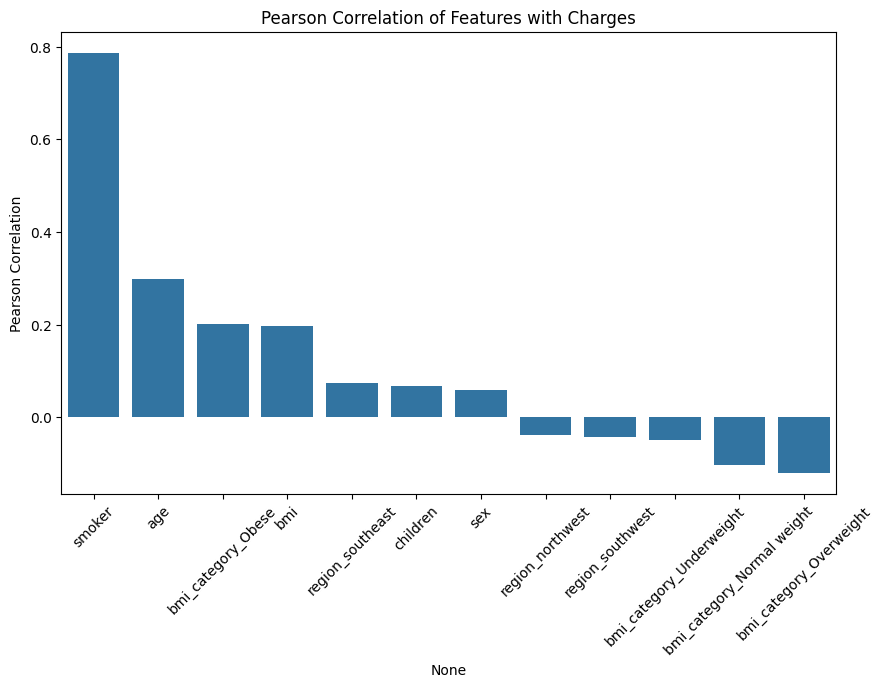

In [27]:
#plotting the correlation of features with charges
plt.figure(figsize=(10,6))
sns.barplot(x=correlations_df.index, y=correlations_df["Pearson Correlation"])
plt.title("Pearson Correlation of Features with Charges")   
plt.xticks(rotation=45)
plt.show()        

In [28]:
#chi_square test for categorical features with charges
from scipy.stats import chi2_contingency
categorical_features = df_cleaned.drop(columns=["age", "bmi", "children","charges"]).columns
print(categorical_features)

alpha=0.05

df_cleaned['charges_category'] = pd.qcut(df_cleaned['charges'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df_cleaned.head()


Index(['sex', 'smoker', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Normal weight', 'bmi_category_Obese',
       'bmi_category_Overweight', 'bmi_category_Underweight'],
      dtype='str')


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight,charges_category
0,-1.440418,0,-0.517949,-0.909234,1,16884,0,0,1,0,0,1,0,Very High
1,-1.511647,1,0.462463,-0.079442,0,1725,0,1,0,0,1,0,0,Low
2,-0.799350,1,0.462463,1.580143,0,4449,0,1,0,0,1,0,0,Low
3,-0.443201,1,-1.334960,-0.909234,0,21984,1,0,0,1,0,0,0,Very High
4,-0.514431,1,-0.354547,-0.909234,0,3866,1,0,0,0,0,1,0,Low


In [29]:
#chi2 test for categorical features
chi2_results = {}
for feature in categorical_features:
    contingency_table = pd.crosstab(df_cleaned[feature], df_cleaned['charges_category'])
    chi2_stat,p_value,_,_ = chi2_contingency(contingency_table)
    decision = "Reject Null Hypothesis(Keep feature)" if p_value < alpha else "Accept Null Hypothesis(Drop the feature)"
    chi2_results[feature]={
        "chi2_stat": chi2_stat,
        "p_value": p_value,
        "Decision":decision,
    }

chi2_results_df = pd.DataFrame.from_dict(chi2_results, orient="index")
chi2_results_df.sort_values(by="p_value", inplace=True)
chi2_results_df



,chi2_stat,p_value,Decision
smoker,848.219178,1.507478e-183,Reject Null Hypothesis(Keep feature)
region_southeast,15.998167,1.134966e-03,Reject Null Hypothesis(Keep feature)
sex,10.258784,1.648974e-02,Reject Null Hypothesis(Keep feature)
bmi_category_Obese,8.515711,3.647336e-02,Reject Null Hypothesis(Keep feature)
region_southwest,5.091893,1.651906e-01,Accept Null Hypothesis(Drop the feature)
bmi_category_Overweight,4.251490,2.355571e-01,Accept Null Hypothesis(Drop the feature)
bmi_category_Normal weight,3.708088,2.947595e-01,Accept Null Hypothesis(Drop the feature)
bmi_category_Underweight,3.374030,3.374713e-01,Accept Null Hypothesis(Drop the feature)
region_northwest,1.134240,7.688154e-01,Accept Null Hypothesis(Drop the feature)


In [30]:
#final dataset after feature selection
final_df = df_cleaned.drop(columns=["region_northwest", "region_southwest","bmi_category_Underweight","bmi_category_Normal weight","bmi_category_Overweight","charges_category"])
final_df.head()

,age,sex,bmi,children,smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,0,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,1,0.462463,-0.079442,0,1725,1,1
2,-0.799350,1,0.462463,1.580143,0,4449,1,1
3,-0.443201,1,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,1,-0.354547,-0.909234,0,3866,0,0


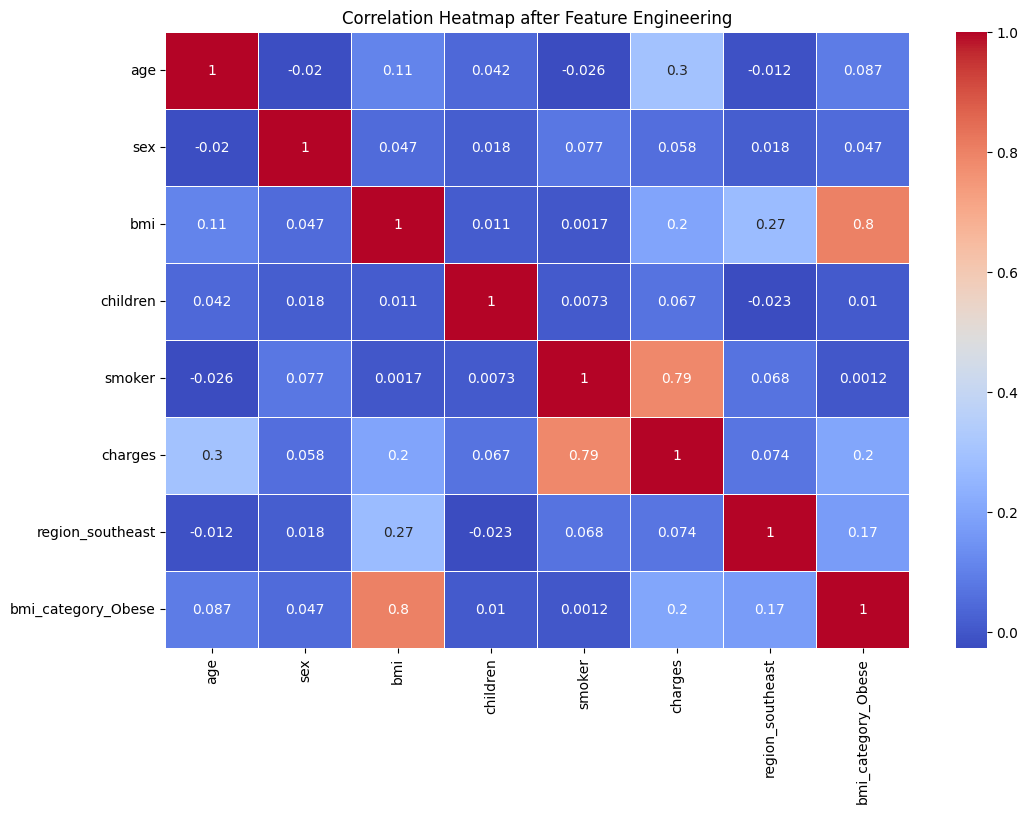

In [31]:
#correlation heatmap after feature engineering
plt.figure(figsize=(12, 8))
sns.heatmap(final_df.corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap after Feature Engineering")
plt.show()

In [32]:
#train test split
from sklearn.model_selection import train_test_split
X = final_df.drop(columns=["charges"])
y = final_df["charges"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1069, 7), (268, 7), (1069,), (268,))

In [33]:
#model training
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
#Accuracy evaluation using R2 score
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2:.4f}")


R2 Score: 0.8041


In [35]:
#Adjusted R2 Score
n = X_test.shape[0]  # number of samples
p = X_test.shape[1]  # number of features
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"Adjusted R2 Score: {adjusted_r2:.4f}")


Adjusted R2 Score: 0.7988


In [36]:
#Accuracy,precision,recall,f1-score
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")


Mean Absolute Error: 4295.1978
Mean Squared Error: 36003101.6524
